# Airbnb market EDA, ETL and Visualization
#### https://www.kaggle.com/datasets/jasonairroi/airbnb-market-data-europe

In [2]:
# Importing libraries
#%pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Setting up libraries configurations

# Pandas:
pd.set_option('display.max_rows', 61)
pd.set_option('display.max_row', 61)
pd.set_option('display.date_yearfirst', True)
pd.option_context('display.max_rows', None)

# Listings:

In [4]:
# Constants
LISTING_DATASET = "../data/listings.parquet"
EXACT_COLUMNS_LISTINGS = ['listing_id', 'listing_type', 'room_type', 'cover_photo_url', 'photos_count', 'host_id', 
                'superhost', 'latitude', 'longitude', 'guests', 'bedrooms', 'beds', 'baths', 'registration', 
                'amenities', 'instant_book', 'professional_management', 'min_nights', 'cancellation_policy', 
                'currency', 'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall', 'rating_accuracy', 
                'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 
                'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate', 'ttm_avg_rate_native', 'ttm_occupancy', 
                'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar',
                'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days', 
                'ttm_total_days', 'l90d_revenue', 'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native', 
                'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_revpar_native', 
                'l90d_adjusted_revpar', 'l90d_adjusted_revpar_native', 'l90d_reserved_days', 'l90d_blocked_days', 
                'l90d_available_days', 'l90d_total_days', 'country', 'state', 'city'
]
TARGET_COLS = ['ttm_revenue']

In [5]:
# Reading data
df_pqt = pd.read_parquet(LISTING_DATASET)
df_pqt.head()

,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city
0,121902,Entire home,entire_home,https://a0.muscache.com/im/pictures/77c0e3a9-0...,77,fe453949b595,false,37.0758,27.2426,6,...,0.0,0.0,0.0,0,90,90,90,Turkey,Muğla,Bodrum
1,805342,Entire condo,entire_home,https://a0.muscache.com/im/pictures/11494599/4...,16,59711ec4c245,false,37.0092,27.2563,3,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum
2,805361,Entire home,entire_home,https://a0.muscache.com/im/pictures/bda48dbc-d...,34,d217bf6e3427,false,37.0292,27.4410,5,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum
3,853827,Entire villa,entire_home,https://a0.muscache.com/im/pictures/26626113/a...,70,605fc7d80e02,false,37.0434,27.2517,16,...,536.3,0.0,0.0,2,0,88,90,Turkey,Muğla,Bodrum
4,967193,Entire villa,entire_home,https://a0.muscache.com/im/pictures/68107669/2...,37,3b963e8cd040,false,37.0429,27.3898,4,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum


In [6]:
# Analysing columns
print(list(df_pqt.columns) == EXACT_COLUMNS_LISTINGS)

True


In [7]:
# Checking Non-Nulls, Nulls and Columns types
non_null_count_listings = df_pqt.notnull().sum().values
nulls = df_pqt.isna().sum()
types = df_pqt.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_listings,
    'Null Count': nulls,
    'Dtypes': types
})
print(info_df)


                             Non-Null Count  Null Count Dtypes
listing_id                            95898           0    str
listing_type                          95329         569    str
room_type                             95329         569    str
cover_photo_url                       95102         796    str
photos_count                          95102         796    str
host_id                               95329         569    str
superhost                             95322         576    str
latitude                              95327         571    str
longitude                             95273         625    str
guests                                84865       11033    str
bedrooms                              78576       17322    str
beds                                  94336        1562    str
baths                                 94994         904    str
registration                          95064         834    str
amenities                             94960         938

In [8]:
# Defining correct columns dtypes

str_cols = [
    'listing_type', 'room_type', 'cover_photo_url', 'host_id', 'amenities', 'cancellation_policy', 
    'currency', 'country', 'state', 'city'
]

bool_cols = [
    'superhost', 'registration', 'instant_book', 'professional_management'
]

float_cols = [
    'latitude', 'longitude', 'beds', 'baths', 'rating_overall', 'rating_accuracy', 'rating_checkin', 
    'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'ttm_avg_rate', 
    'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_revpar_native',
    'ttm_adjusted_revpar', 'ttm_adjusted_revpar_native', 'l90d_avg_rate', 'l90d_avg_rate_native', 
    'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_revpar_native', 'l90d_adjusted_revpar', 
    'l90d_adjusted_revpar_native'
]

int_cols = [
    'listing_id', 'photos_count', 'guests', 'bedrooms', 'min_nights', 
    'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'ttm_revenue', 'ttm_revenue_native',
    'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days', 'ttm_total_days',
    'l90d_revenue', 'l90d_revenue_native', 'l90d_reserved_days', 'l90d_blocked_days',
    'l90d_available_days', 'l90d_total_days'
]

print(len(EXACT_COLUMNS_LISTINGS) == (len(str_cols) + len(bool_cols) + len(float_cols) + len(int_cols)))

True


# ETL

### Removing columns:

In [9]:
# Remove columns:

str_cols_to_remove = ['listing_type', 'cover_photo_url', 'host_id', 'currency', 'state']
float_cols_to_remove = ['latitude', 'longitude',  'ttm_avg_rate_native', 
                'ttm_revpar_native', 'ttm_adjusted_revpar_native',  
                'l90d_avg_rate', 'l90d_avg_rate_native', 'l90d_occupancy', 'l90d_adjusted_occupancy', 
                'l90d_revpar', 'l90d_revpar_native', 'l90d_adjusted_revpar', 'l90d_adjusted_revpar_native',               
]
int_cols_to_remove = ['ttm_revenue_native', 'ttm_total_days', 'l90d_revenue', 'l90d_revenue_native', 
                    'l90d_reserved_days', 'l90d_blocked_days', 'l90d_available_days', 'l90d_total_days'
]
cols_to_remove = str_cols_to_remove + float_cols_to_remove + int_cols_to_remove

df_fixing = df_pqt.drop(cols_to_remove, axis=1)

print(len(EXACT_COLUMNS_LISTINGS) - len(cols_to_remove) == len(df_fixing.columns))
print(len(df_fixing))

True
95898


### Convert (and remove):

In [10]:
# Int: 
#    - "float" --> round() int
#    - else --> NaN
# Float: 
#    - "float" --> float
#    - else --> NaN

# Defining new numeric columns
new_float_cols = [col for col in float_cols if col not in float_cols_to_remove]
new_int_cols = [col for col in int_cols if col not in int_cols_to_remove]
new_numeric_cols = new_float_cols + new_int_cols

# Changing str to numeric
df_fixing[new_numeric_cols] = df_fixing[new_numeric_cols].apply(pd.to_numeric, errors="coerce")

# Changing inf to nan
df_fixing[new_numeric_cols] = df_fixing[new_numeric_cols].replace([np.inf, -np.inf], np.nan)

def safe_convert(series):
    numeric = pd.to_numeric(series, errors="coerce")
    is_whole = numeric == numeric.round()
    return numeric.where(is_whole).astype("Int64")

# Convert float to int where needed
df_fixing[new_int_cols] = df_fixing[new_int_cols].apply(safe_convert)

print(len(df_fixing))

95898


In [11]:
# Booleans: 
#    - NA --> NA
#    - false --> False
#    - true --> True
#    - else --> drop row

for col in bool_cols:
    s = df_fixing[col].astype(str).str.strip().str.lower()
    df_fixing[col] = s.map({"true": True, "false": False}).astype("boolean")

print(df_fixing[bool_cols].dtypes, "\n")   # should show boolean
print(df_fixing[bool_cols].isna().sum())   # count of NAs per column

print(len(df_fixing))

superhost                  boolean
registration               boolean
instant_book               boolean
professional_management    boolean
dtype: object 

superhost                   1052
registration                1317
instant_book               76192
professional_management    11293
dtype: int64
95898


### Drop inconsistent rows (define limits and remove outliers):

In [12]:
df_fixing = df_fixing[
    # Keeping rows with rating between 0 and 5 stars
    ((df_fixing["rating_overall"] >= 0) & (df_fixing["rating_overall"] <= 5)) &
    ((df_fixing["rating_accuracy"] >= 0) & (df_fixing["rating_accuracy"] <= 5)) &
    ((df_fixing["rating_checkin"] >= 0) & (df_fixing["rating_checkin"] <= 5)) &
    ((df_fixing["rating_cleanliness"] >= 0) & (df_fixing["rating_cleanliness"] <= 5)) &
    ((df_fixing["rating_communication"] >= 0) & (df_fixing["rating_communication"] <= 5)) &
    ((df_fixing["rating_location"] >= 0) & (df_fixing["rating_location"] <= 5)) &
    ((df_fixing["rating_value"] >= 0) & (df_fixing["rating_value"] <= 5)) &
    
    # Kepping rows with more than 0 days/nights 
    (df_fixing["ttm_reserved_days"] >= 0) &
    (df_fixing["ttm_blocked_days"] >= 0) &
    (df_fixing["ttm_available_days"] >= 0) &
    (df_fixing["min_nights"] >= 0) &

    # Keeping rows with reasonable amount of photos_count
    (df_fixing["photos_count"] <= 100)
]

print(len(df_fixing))

90349


In [13]:
cols_check_outliers = ['guests', 'beds', 'bedrooms', 'baths']
df = df_fixing[cols_check_outliers].dropna()

# ratio features — extreme values flag bad listings
df['guests_per_bed']      = df['guests'] / df['beds'].replace(0, 1)
df['beds_per_bedroom']    = df['beds'] / df['bedrooms'].replace(0, 1)
df['guests_per_bedroom']  = df['guests'] / df['bedrooms'].replace(0, 1)

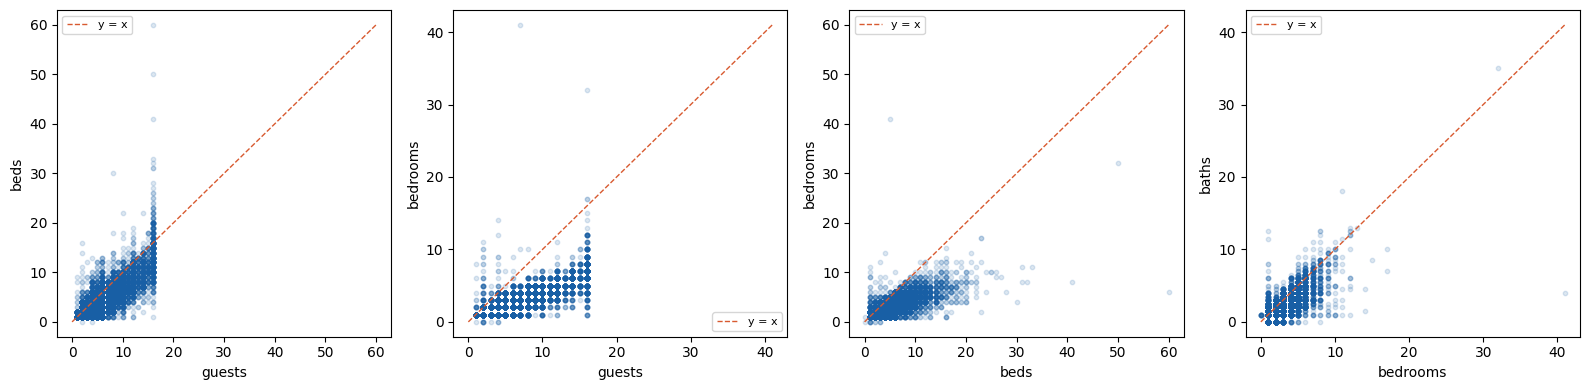

In [14]:
pairs = [
    ('guests', 'beds'),
    ('guests', 'bedrooms'),
    ('beds', 'bedrooms'),
    ('bedrooms', 'baths'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.15, s=10, color='#185FA5')
    ax.set_xlabel(x); ax.set_ylabel(y)
    # reference line: y should be ≤ x for most pairs
    lim = max(df[x].max(), df[y].max())
    ax.plot([0, lim], [0, lim], '--', color='#D85A30',
            linewidth=1, label='y = x')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
# IQR-based flagging per column
def iqr_outliers(series, k=1.5):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - k*IQR) | (series > Q3 + k*IQR)

flags = pd.DataFrame({col: iqr_outliers(df[col]) for col in cols_check_outliers})
df['is_outlier'] = flags.any(axis=1)

# hard business rules
df['suspicious'] = (
    (df['beds'] > df['guests'] * 2)   |   # way more beds than guests
    (df['bedrooms'] > df['beds'] + 2) |   # more bedrooms than beds
    (df['guests_per_bed'] > 4)                 # too many guests per bed
)

print(df[['guests','beds','bedrooms','baths','is_outlier','suspicious']]
        [df['suspicious']]
       .head(20))

      guests  beds  bedrooms  baths  is_outlier  suspicious
42         4   9.0         2    1.0        True        True
100        2   1.0         5    1.0        True        True
103        2  14.0        10    1.0        True        True
213        2   1.0         5    1.0        True        True
336        4   9.0         2    1.0        True        True
340        5   1.0         1    1.0       False        True
498        5   1.0         1    1.0       False        True
505        5  12.0         2    1.0        True        True
540       16   1.0         1    1.0        True        True
1494       5   1.0         1    1.5       False        True
2207       5   1.0         1    0.0        True        True
2367       5   1.0         1    1.0       False        True
2372       5   1.0         1    1.0       False        True
2672      10   2.0         5    5.0        True        True
2685       2   1.0        11    1.0        True        True
3802      16   3.0         1    1.0     

In [16]:
# keep only non-suspicious rows
df_clean = df[~df['suspicious']].copy()

print(f"Rows before: {len(df)}")
print(f"Rows removed: {df['suspicious'].sum()}")
print(f"Rows after: {len(df_clean)}")

Rows before: 72975
Rows removed: 368
Rows after: 72607


In [17]:
df_fixing = df_fixing.loc[df_clean.index].copy()

### Adding column

In [18]:
# Add column:
# - amenities_count

all_amenities = set(str())

amenities_counts = list()

df_fixing = df_fixing.dropna(subset="amenities")

for i in range(len(df_fixing)):
    amenities = df_fixing["amenities"].iloc[i].split(",")

    all_amenities.update(amenities)
    amenities_counts.append(len(amenities))

df_fixing.insert(13, "amenities_count", amenities_counts)

new_numeric_cols.insert(4, "amenities_count")

print(df_fixing.columns)

Index(['listing_id', 'room_type', 'photos_count', 'superhost', 'guests',
       'bedrooms', 'beds', 'baths', 'registration', 'amenities',
       'instant_book', 'professional_management', 'min_nights',
       'amenities_count', 'cancellation_policy', 'cleaning_fee',
       'extra_guest_fee', 'num_reviews', 'rating_overall', 'rating_accuracy',
       'rating_checkin', 'rating_cleanliness', 'rating_communication',
       'rating_location', 'rating_value', 'ttm_revenue', 'ttm_avg_rate',
       'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_revpar',
       'ttm_adjusted_revpar', 'ttm_reserved_days', 'ttm_blocked_days',
       'ttm_available_days', 'country', 'city'],
      dtype='str')


In [19]:
print(len(all_amenities))

135


### Creating new clean .parquet file

In [20]:
# Creating new clean .parquet file
df_fixing.to_parquet(path="../data/clean_listings.parquet")

df_clean = pd.read_parquet("../data/clean_listings.parquet")

# Visualize

#### Tables:
1. Basic Overview
2. Distributions of key numeric columns
3. Revenue & performance analysis
4. Correlation analysis
5. Geographic analysis
6. Correlation heatmap (numeric columns)
7. Amenities analysis

#### 1. Basic Overview

In [21]:
non_null_count_listings = df_clean.notnull().sum().values
nulls = df_clean.isna().sum()
types = df_clean.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_listings,
    'Null Count': nulls,
    'Dtypes': types
})

print(info_df)
#print(len(df_clean.columns))
cols_check_outliers = list(df_clean.columns)
inputs = ['room_type', 'photos_count', 'superhost', 'guests', 'bedrooms', 'beds', 'baths', 
          'amenities_count', 'cleaning_fee', 'num_reviews', 'rating_overall', 'ttm_occupancy',
            'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_adjusted_revpar', 'ttm_reserved_days', 
            'ttm_blocked_days', 'ttm_available_days', 'country', 'city']
removed = [col for col in cols_check_outliers if col not in inputs]
print(len(df_clean.columns), len(inputs), len(removed))
print(removed)

                         Non-Null Count  Null Count   Dtypes
listing_id                        72588          16    Int64
room_type                         72604           0      str
photos_count                      72604           0    Int64
superhost                         72604           0  boolean
guests                            72604           0    Int64
bedrooms                          72604           0    Int64
beds                              72604           0  float64
baths                             72604           0  float64
registration                      72364         240  boolean
amenities                         72604           0      str
instant_book                      15123       57481  boolean
professional_management           64541        8063  boolean
min_nights                        72604           0    Int64
amenities_count                   72604           0    int64
cancellation_policy               72593          11      str
cleaning_fee            

#### 2. Distributions of key numeric columns

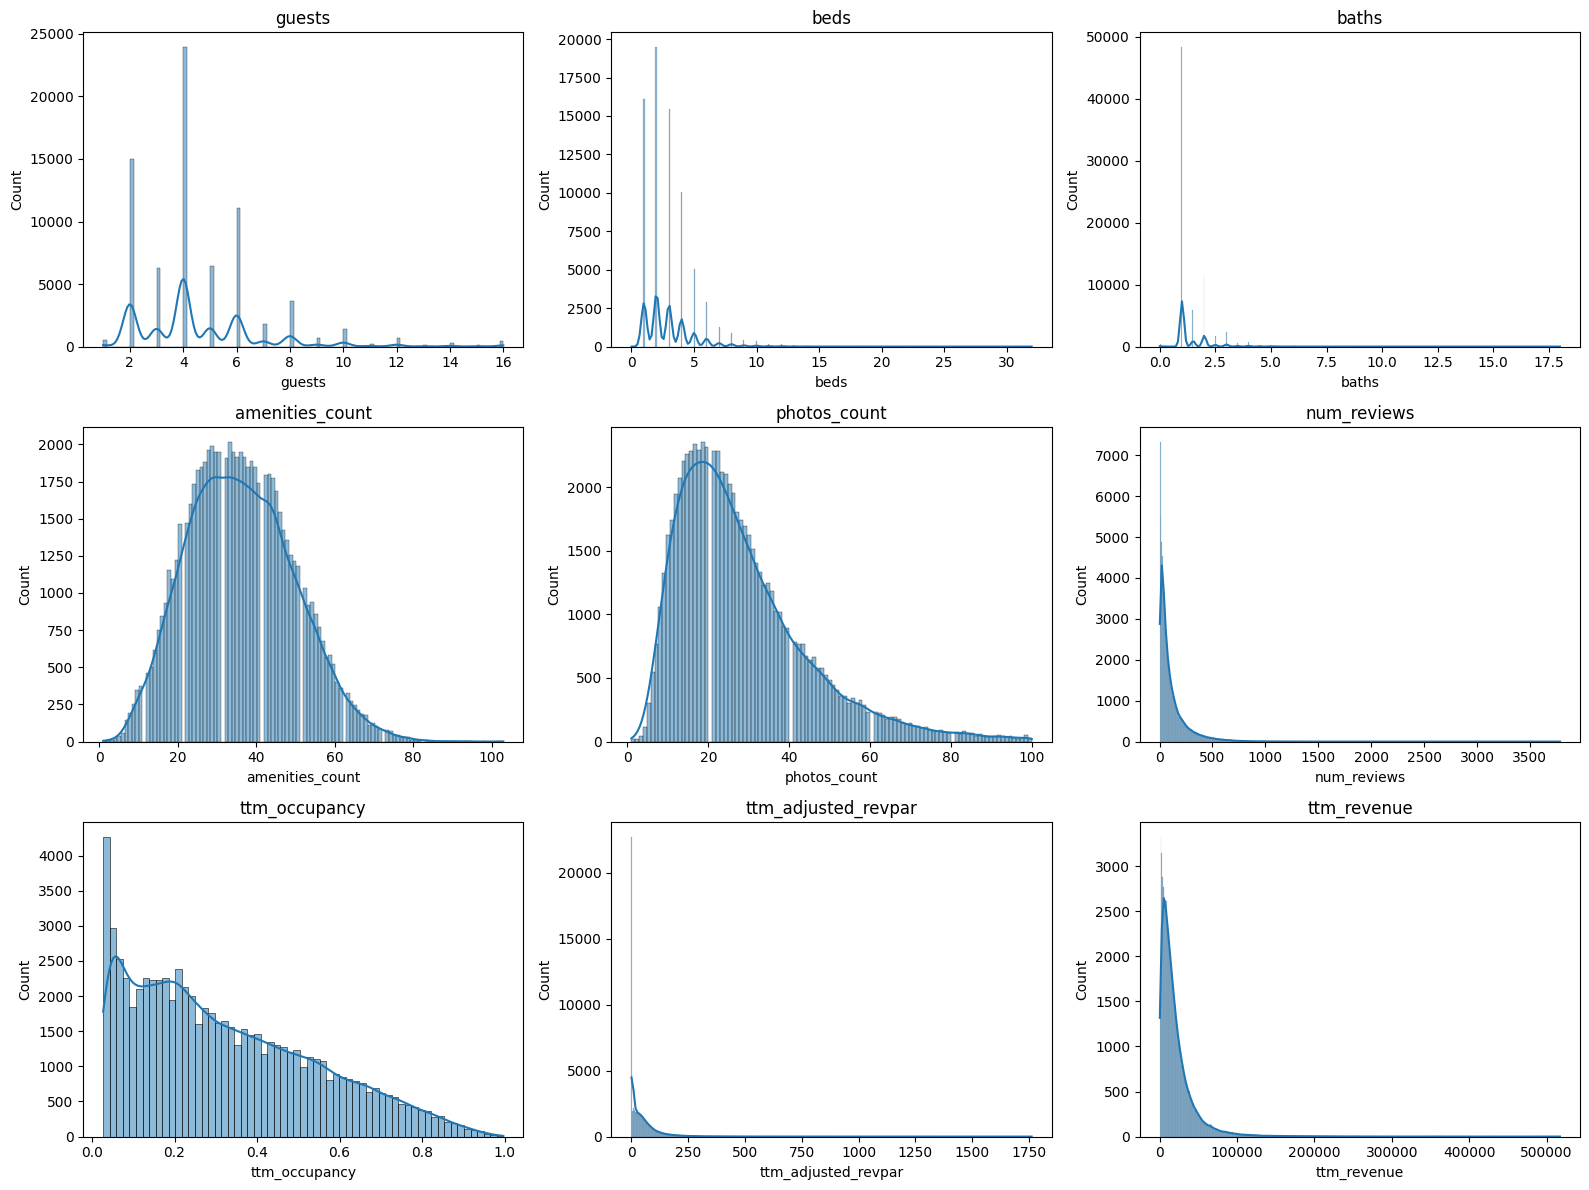

In [22]:
key_numeric_cols = ['guests', 'beds', 'baths', 'amenities_count', 'photos_count', 'num_reviews', 
                    'ttm_occupancy', 'ttm_adjusted_revpar', 'ttm_revenue'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flatten(), key_numeric_cols):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()


#### 3. Revenue & performance analysis

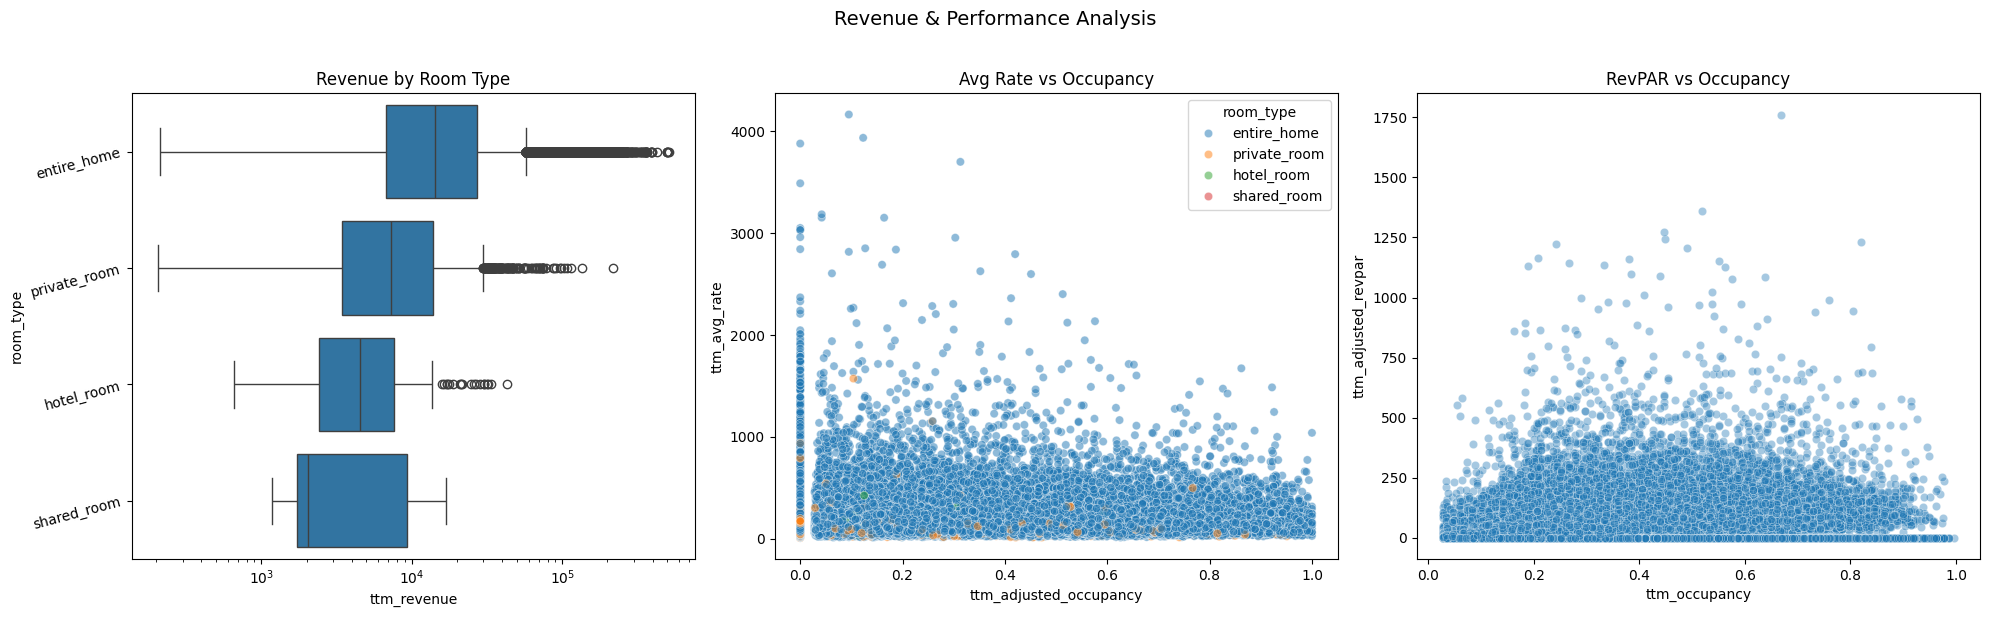

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Revenue by room type
sns.boxplot(data=df_clean, x="ttm_revenue", y="room_type", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Revenue by Room Type")
axes[0].tick_params(axis="y", rotation=15)

# Occupancy vs avg rate
sns.scatterplot(data=df_clean, x="ttm_adjusted_occupancy", y="ttm_avg_rate", 
                hue="room_type", alpha=0.5, ax=axes[1])
axes[1].set_title("Avg Rate vs Occupancy")

# RevPAR vs occupancy
sns.scatterplot(data=df_clean, x="ttm_occupancy", y="ttm_adjusted_revpar",
                alpha=0.4, ax=axes[2])
axes[2].set_title("RevPAR vs Occupancy")

plt.suptitle("Revenue & Performance Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
df_clean.groupby("room_type")["ttm_revenue"].mean()

room_type
entire_home     21383.900934
hotel_room       6847.329412
private_room    11156.413545
shared_room           6221.8
Name: ttm_revenue, dtype: Float64

#### 4. Correlation analysis

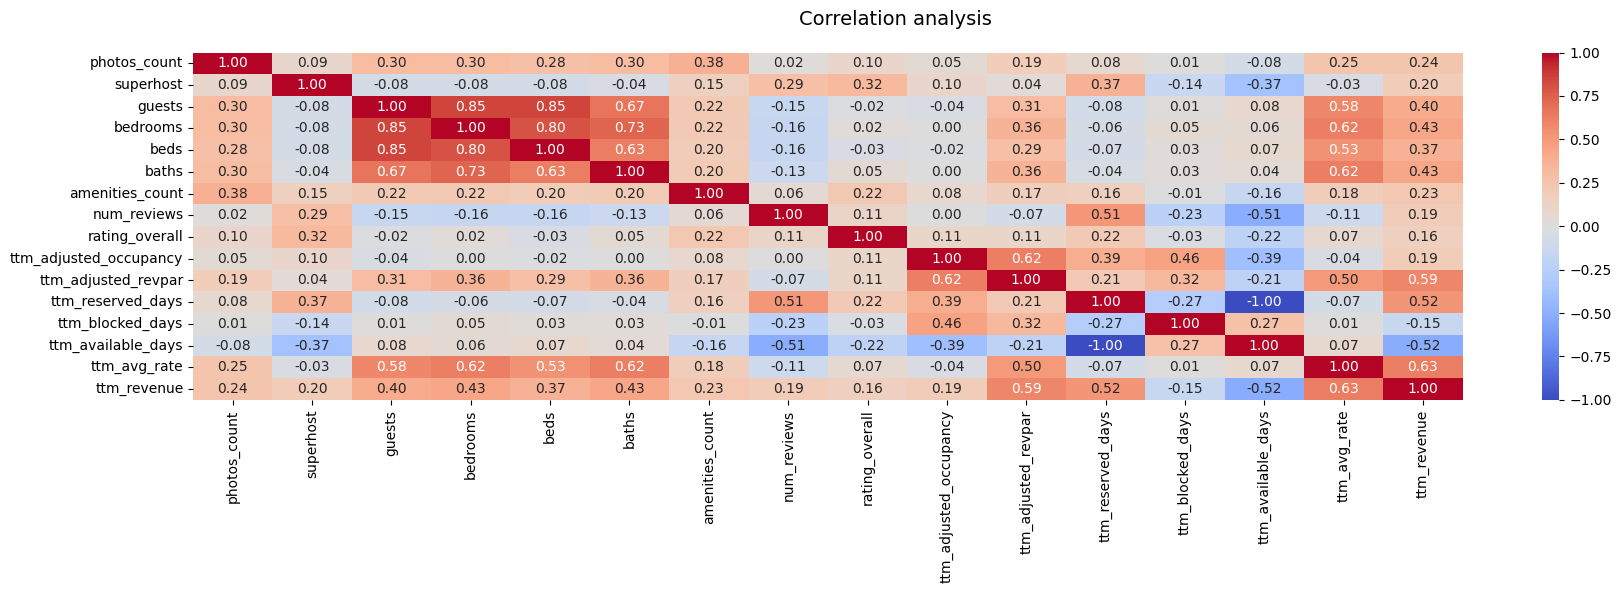

In [ ]:

corr_cols = [
       'photos_count', 'superhost', 'guests', 'bedrooms', 'beds', 'baths', 'amenities_count','num_reviews', 
       'rating_overall', 'ttm_adjusted_occupancy', 'ttm_adjusted_revpar', 'ttm_reserved_days', 
       'ttm_blocked_days', 'ttm_available_days', 'ttm_avg_rate', 'ttm_revenue', 
]

fig, axes = plt.subplots(figsize=(18, 6))

# Correlation heatmap
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
)

plt.suptitle("Correlation analysis", fontsize=14)
plt.tight_layout()
plt.show()

#### 5. Geographic analysis

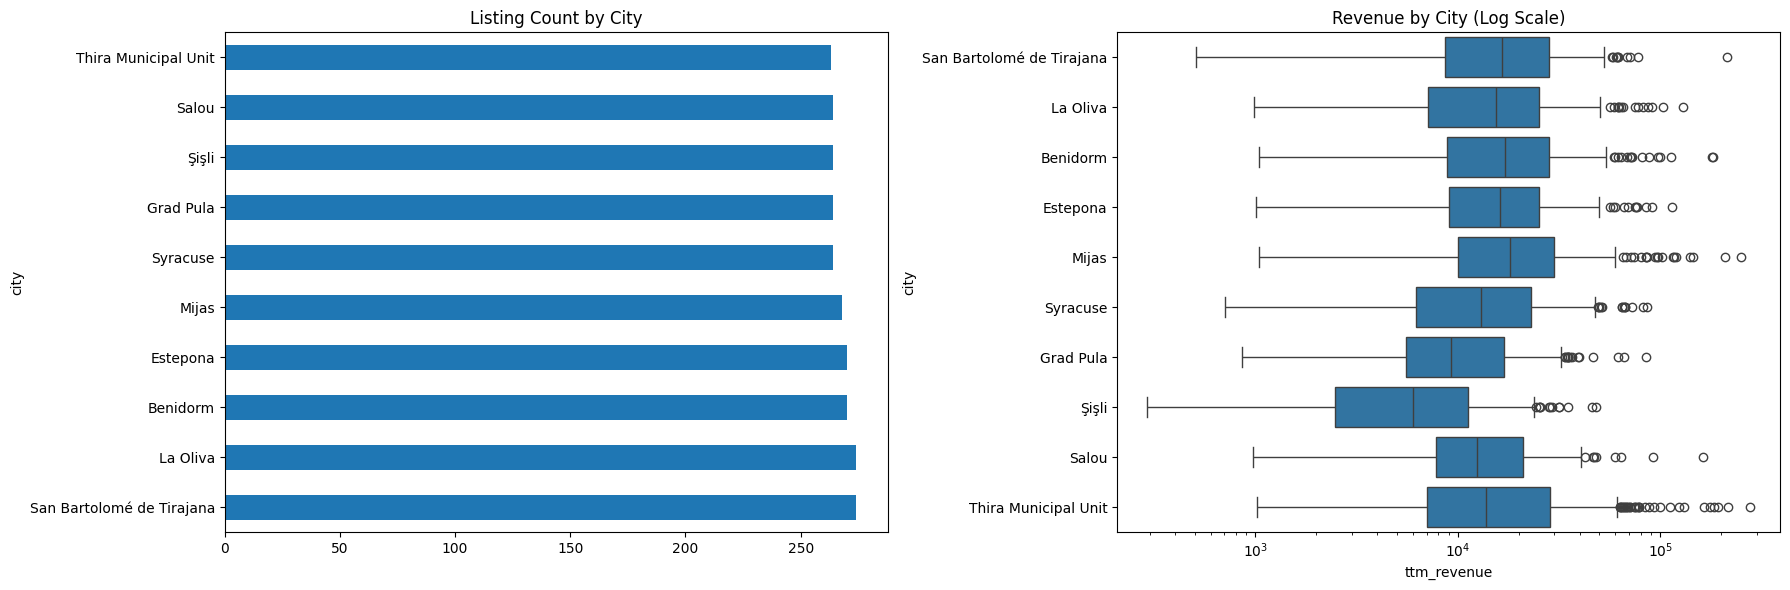

city
San Bartolomé de Tirajana    274
La Oliva                     274
Benidorm                     270
Estepona                     270
Mijas                        268
                            ... 
Lausanne                      97
Basel                         94
Galway                        93
Salford                       93
Cambridge                     82
Name: count, Length: 372, dtype: int64

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cities = df_clean["city"].value_counts().head(10).index

# Listing count by city
df_clean["city"].value_counts().head(10).plot(kind="barh", ax=axes[0])
axes[0].set_title("Listing Count by City")

# Revenue by city
sns.boxplot(data=df_clean[df_clean["city"].isin(top_cities)], 
            x="ttm_revenue", y="city", 
            order=top_cities, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Revenue by City (Log Scale)")

plt.tight_layout()
plt.show()
df_clean["city"].value_counts()

#### 6. Correlation heatmap (numeric columns)


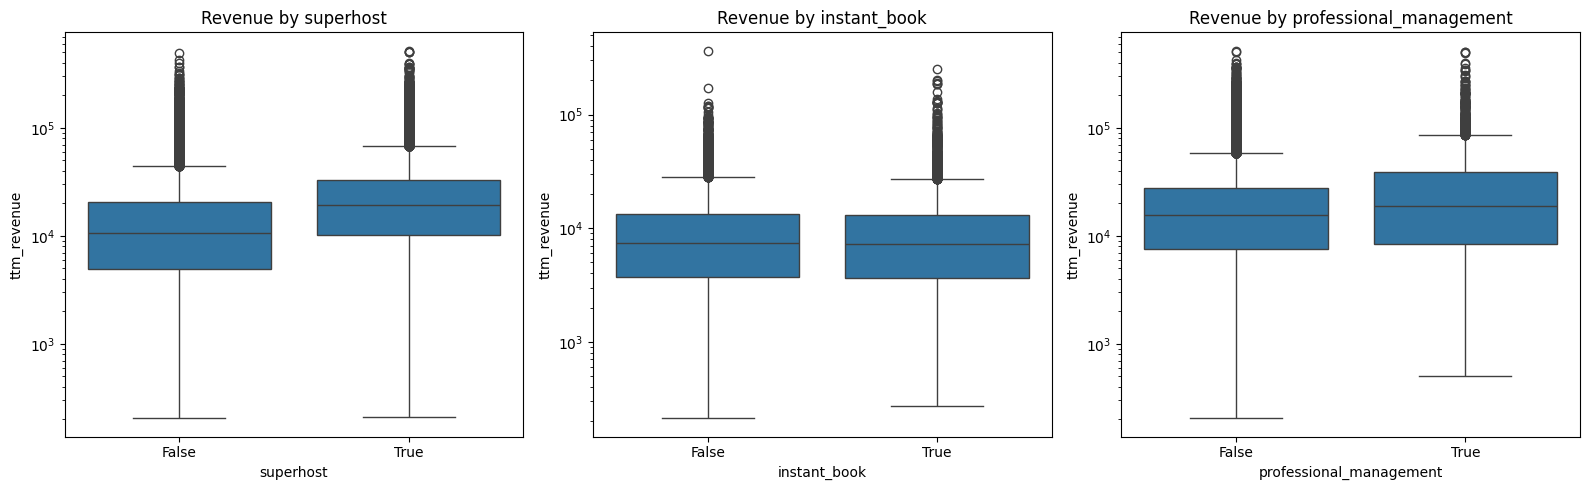

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["superhost", "instant_book", "professional_management"]):
    data = df_clean.copy()
    data[col] = data[col].astype(str)
    sns.boxplot(data=data, x=col, y="ttm_revenue", ax=ax)
    ax.set_yscale("log")  # log on y (revenue), not x (boolean category)
    ax.set_title(f"Revenue by {col}")
plt.tight_layout()

#### 7. Amenities analysis

Text(0.5, 1.0, 'Top 20 Amenities')

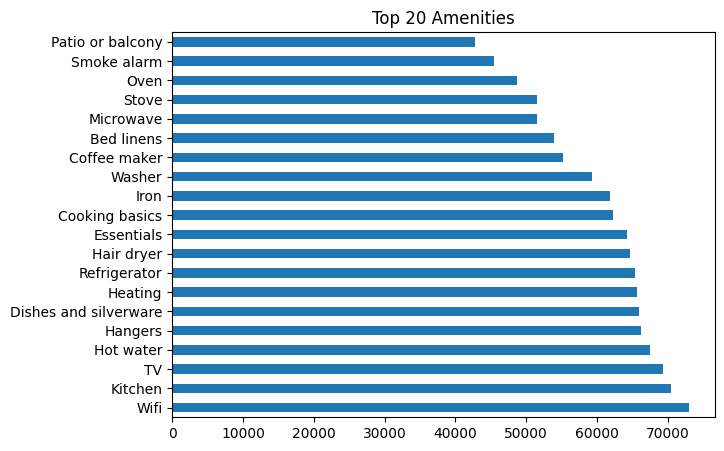

In [26]:
# Most common amenities (assuming comma-separated string)
from collections import Counter

all_amenities = df_clean["amenities"].dropna().str.split(",").explode().str.strip()
top_amenities = pd.Series(Counter(all_amenities)).sort_values(ascending=False).head(20)
top_amenities.plot(kind="barh", figsize=(7, 5))
plt.title("Top 20 Amenities")